In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print("Final Data Shape:", df.shape)

Final Data Shape: (7032, 21)


In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Null values in TotalCharges:", df['TotalCharges'].isnull().sum())
df.dropna(inplace=True)
print("\n--- Final Cleaned Data Summary ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\nData Types of Important Columns:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dtypes)

Null values in TotalCharges: 0

--- Final Cleaned Data Summary ---
Total Rows: 7032
Total Columns: 21

Data Types of Important Columns:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
Churn              object
dtype: object


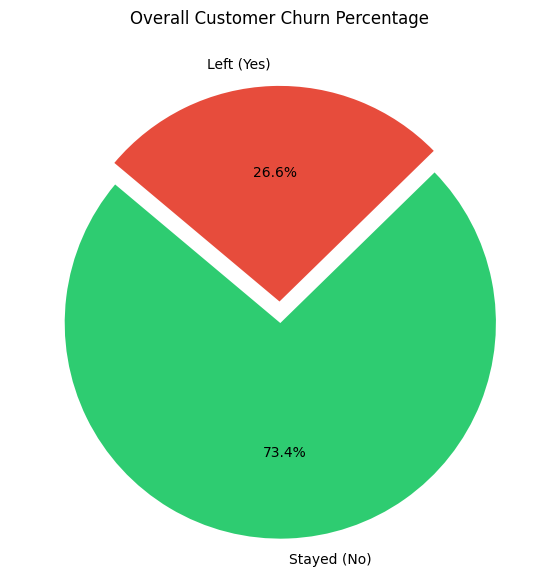

Total Customers Analyzed: 7032


In [21]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(churn_counts, labels=['Stayed (No)', 'Left (Yes)'],
        autopct='%1.1f%%', startangle=140,
        colors=['#2ecc71','#e74c3c'], explode=(0.1, 0))

plt.title('Overall Customer Churn Percentage')
plt.show()

print(f"Total Customers Analyzed: {df.shape[0]}")

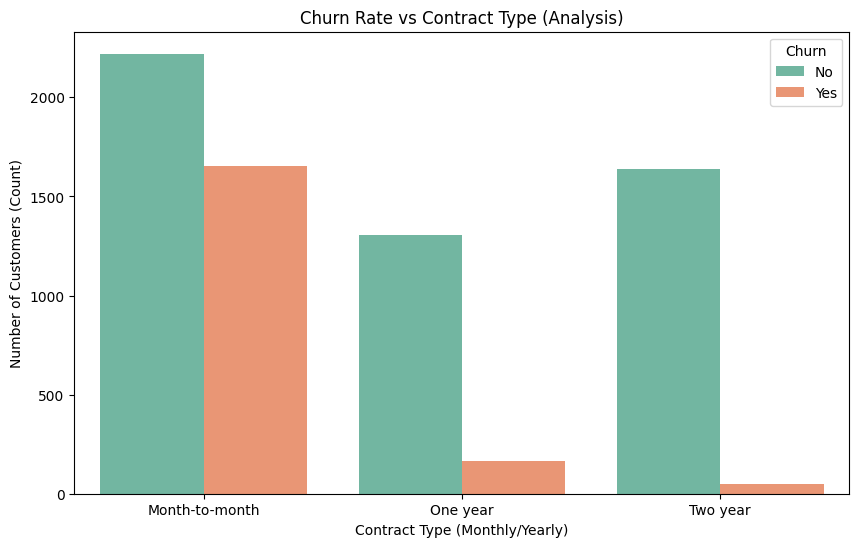

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn Rate vs Contract Type (Analysis)')
plt.xlabel('Contract Type (Monthly/Yearly)')
plt.ylabel('Number of Customers (Count)')
plt.show()

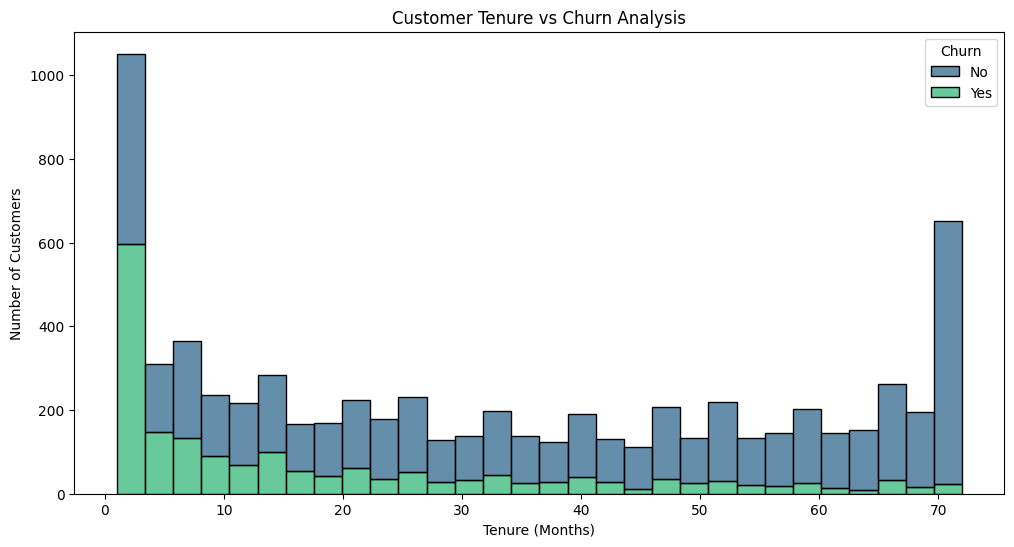

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis', bins=30)
plt.title('Customer Tenure vs Churn Analysis')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

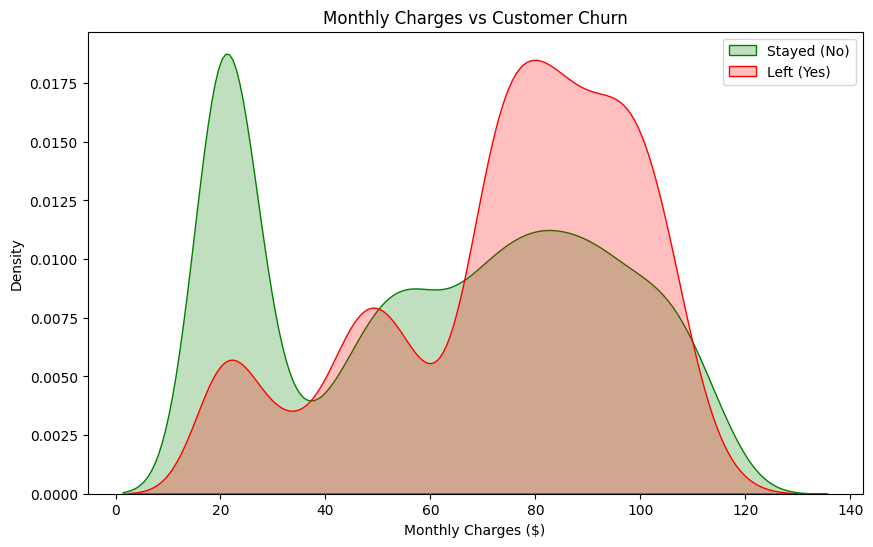

In [24]:
plt.figure(figsize=(10,6))
sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ], color="Green", fill=True, label="Stayed (No)")
sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ], color="Red", fill=True, label="Left (Yes)")
plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [25]:
df.to_csv('Cleaned_Customer_Churn.csv', index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### Data Preparation and Splitting

In [26]:

df_ml = df.drop('customerID', axis=1)
df_ml['Churn'] = df_ml['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
categorical_cols = df_ml.select_dtypes(include='object').columns
numerical_cols = df_ml.select_dtypes(include=['int64', 'float64']).columns.drop('Churn', errors='ignore')

# Apply one-hot encoding to categorical features
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Scale numerical features (only those identified before one-hot encoding to avoid scaling dummy variables)
# Ensure numerical_cols aligns with columns in X after get_dummies
# Filter numerical_cols to only include those present in X after one-hot encoding
actual_numerical_cols_in_X = [col for col in numerical_cols if col in X.columns]

scaler = StandardScaler()
X[actual_numerical_cols_in_X] = scaler.fit_transform(X[actual_numerical_cols_in_X])

print("Data preparation complete. Shape of features (X):", X.shape)
print("First 5 rows of prepared features:")
display(X.head())

Data preparation complete. Shape of features (X): (7032, 30)
First 5 rows of prepared features:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.440327,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,-0.440327,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,-0.440327,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,-0.440327,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,-0.440327,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [27]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


In [28]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Accuracy Score: 0.8038379530916845

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



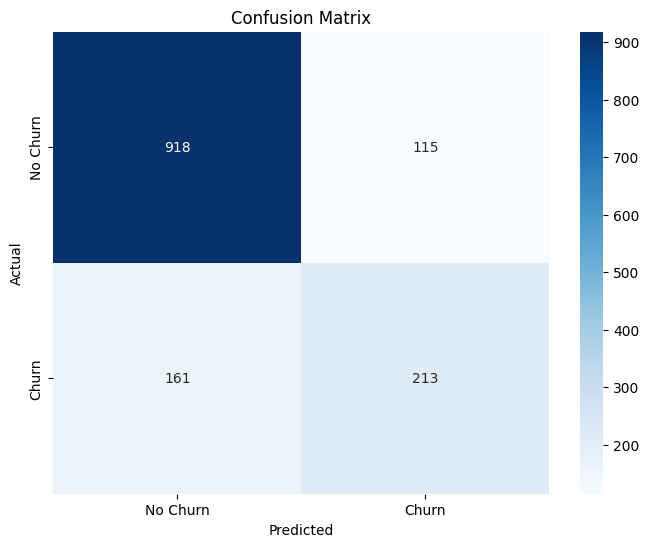

In [29]:
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


Random Forest Accuracy Score: 0.7896233120113717

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



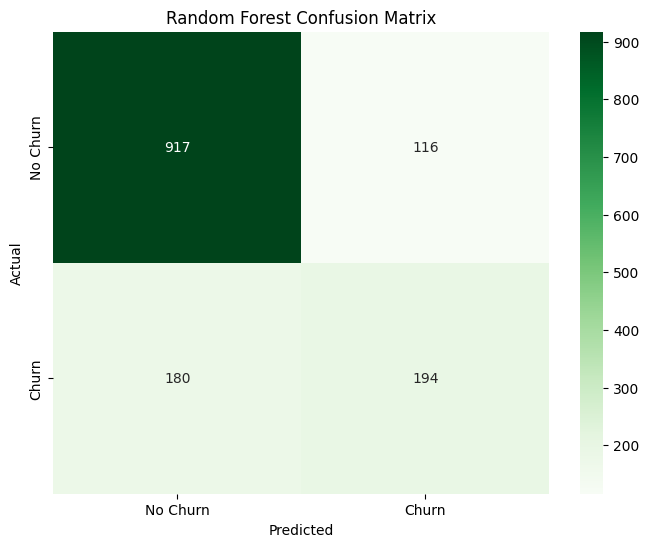

In [31]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [33]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']